# Link Budget

$\Rightarrow$ [Jump to Linkbudget Simulation](#link-budget-simulation)

---

By calculating the link budget of the telemetry system, either the maximum range of the system or individual parameters, such as transmit power, can be determined at a fixed range. A detailed explanation of the link budget can be found [here](https://s.campbellsci.com/documents/us/technical-papers/link-budget.pdf). Additional informations are available [here](https://en.wikipedia.org/wiki/Link_budget) and [here](https://www.sss-mag.com/pdf/an9804.pdf).

The general formula for a link budget describes the signal strength at the receiver and includes components that either increase (positive sign) or decrease (negative sign) the received strength. All values are given in dB (or dBm and dBi).

$P_\text{RX} = P_\text{TX} + G_\text{TX} - L_\text{TX} - L_\text{FS} - L_\text{M} + G_\text{RX} - L_\text{RX}$

## Transmitter Parameters:
- Transmit Power $P_\text{TX}$ 
Specified in the data sheet of the radio module: $P_\text{TX} = 27$ dBm
- Gain of the Transmitting Antenna $G_\text{TX}$ 
The selected transmitting antenna, a QFH antenna, has negligible gain: $G_\text{TX} = 0$
- Transmission Losses on the Transmitting Side $L_\text{TX}$ 
Includes losses in cables and traces as well as transition losses at connectors or other components. These losses depend on the coaxial cable used, the connectors, and much more, and can only be estimated or measured: $L_\text{TX} < 5$ dB

## Receiver Parameters:
- Signal Strength at the Receiver $P_\text{RX}$ 
The minimum signal strength of the radio module is specified in the data sheet: $P_\text{RX, typ} = -118$ dBm, $P_\text{RX, min} = -114$ dBm
- Gain of the Receiving Antenna $G_\text{RX}$ 
The chosen receiving antenna, a helical antenna, can be designed based on the required gain, with higher gain requiring more precise alignment of the antenna. A good estimate is: $G_\text{RX} = 10$ dBi
- Transmission Losses on the Receiving Side $L_\text{RX}$ 
See $L_\text{TX}$: $L_\text{RX} < 5$ dB

## Path Loss:
- Free Space Attenuation $L_\text{FS}$ 
The free space attenuation describes the reduced power density of an EM wave as the distance from the source increases. The formula is: $L_\text{FS} = 20 \cdot \text{log}\left(\frac{4 \pi r f}{c}\right)$ (with $r$ as the distance to the transmitting antenna and $f$ as the frequency used). For a maximum range of $18$ km, this yields: $L_\text{FS} \approx 116$ dB
- Additional Losses During Propagation $L_\text{M}$ 
These losses include absorption losses in the atmosphere, losses due to diffraction and shadowing, as well as losses due to diffraction at obstacles within the Fresnel zone (potentially occurring as fading). They are difficult to estimate and can only be verified through measurements.

Reflection effects can potentially be calculated and included as described [here](https://s.campbellsci.com/documents/us/technical-papers/link-budget.pdf) in Chapter 5.3. These likely have no effect in our case due to the height of the antennas.

The formula for the link budget can be rearranged to calculate the maximum tolerable losses due to transmission for the maximum desired range. $L_\text{TX} + L_\text{RX} + L_\text{M}$ are the unknown losses here.

$L_\text{TX} + L_\text{RX} + L_\text{M} = P_\text{TX} - P_\text{RX} + G_\text{TX} + G_\text{RX} - L_\text{FS}$

Thus, $L_\text{TX} + L_\text{RX} + L_\text{M} \approx 39$ dB for $P_\text{RX, typ}$ and $L_\text{TX} + L_\text{RX} + L_\text{M} \approx 35$ dB for $P_\text{RX, min}$.

The actual values for $L_\text{TX}$ and $L_\text{RX}$ can be determined through measurements, and the entire formula can be validated and adjusted step by step. If $L_\text{TX}$ and $L_\text{RX}$ are either estimated concretely or measured, only $L_\text{M}$ remains.

For $L_\text{TX} = L_\text{RX} = 3$ dB and $P_\text{RX, min}$, we have $L_\text{M} \approx 29$ dB. This value can be understood as a sort of safety buffer (link margin) for adverse atmospheric conditions, poor estimates, or measurements of other parameters and guarantees a reliable connection. This buffer should never be smaller than $10$ dB and should be greater than $20$ dB or $30$ dB for reliable connections.

If the link margin is too small, the received signal can be amplified using a stronger directional reception antenna or by incorporating an amplifier. If the link margin is comparatively large, for example, the data rate can be increased or the directivity of the receiving antenna can be reduced.


# Link Budget Simulation

## Overview

This simulation calculates the link budget for a simple preset flight profile.
It can be used to verify a stable link during all flight phases.
For more informations about the link budget, please visit our dedicated [document](../../docs/linkbudget.md).

## Installation

1. Make sure you have Python 3.10+ installed.
2. Clone the repository or download the code.
3. Install dependencies

## Usage

1. Change the flight profile parameters in the [python script](linkbudget.py): `h_max`, `d_start`, `d_end`, `t_ascent`
2. Run the python script: `python linkbudget.py`
3. The program will output a plot with a visualisation of the preset flight profile, as well as a plot with the link margin during the flight. The minimal link margin is printed.


Minimal Link Margin during the flight: 28.19 dB


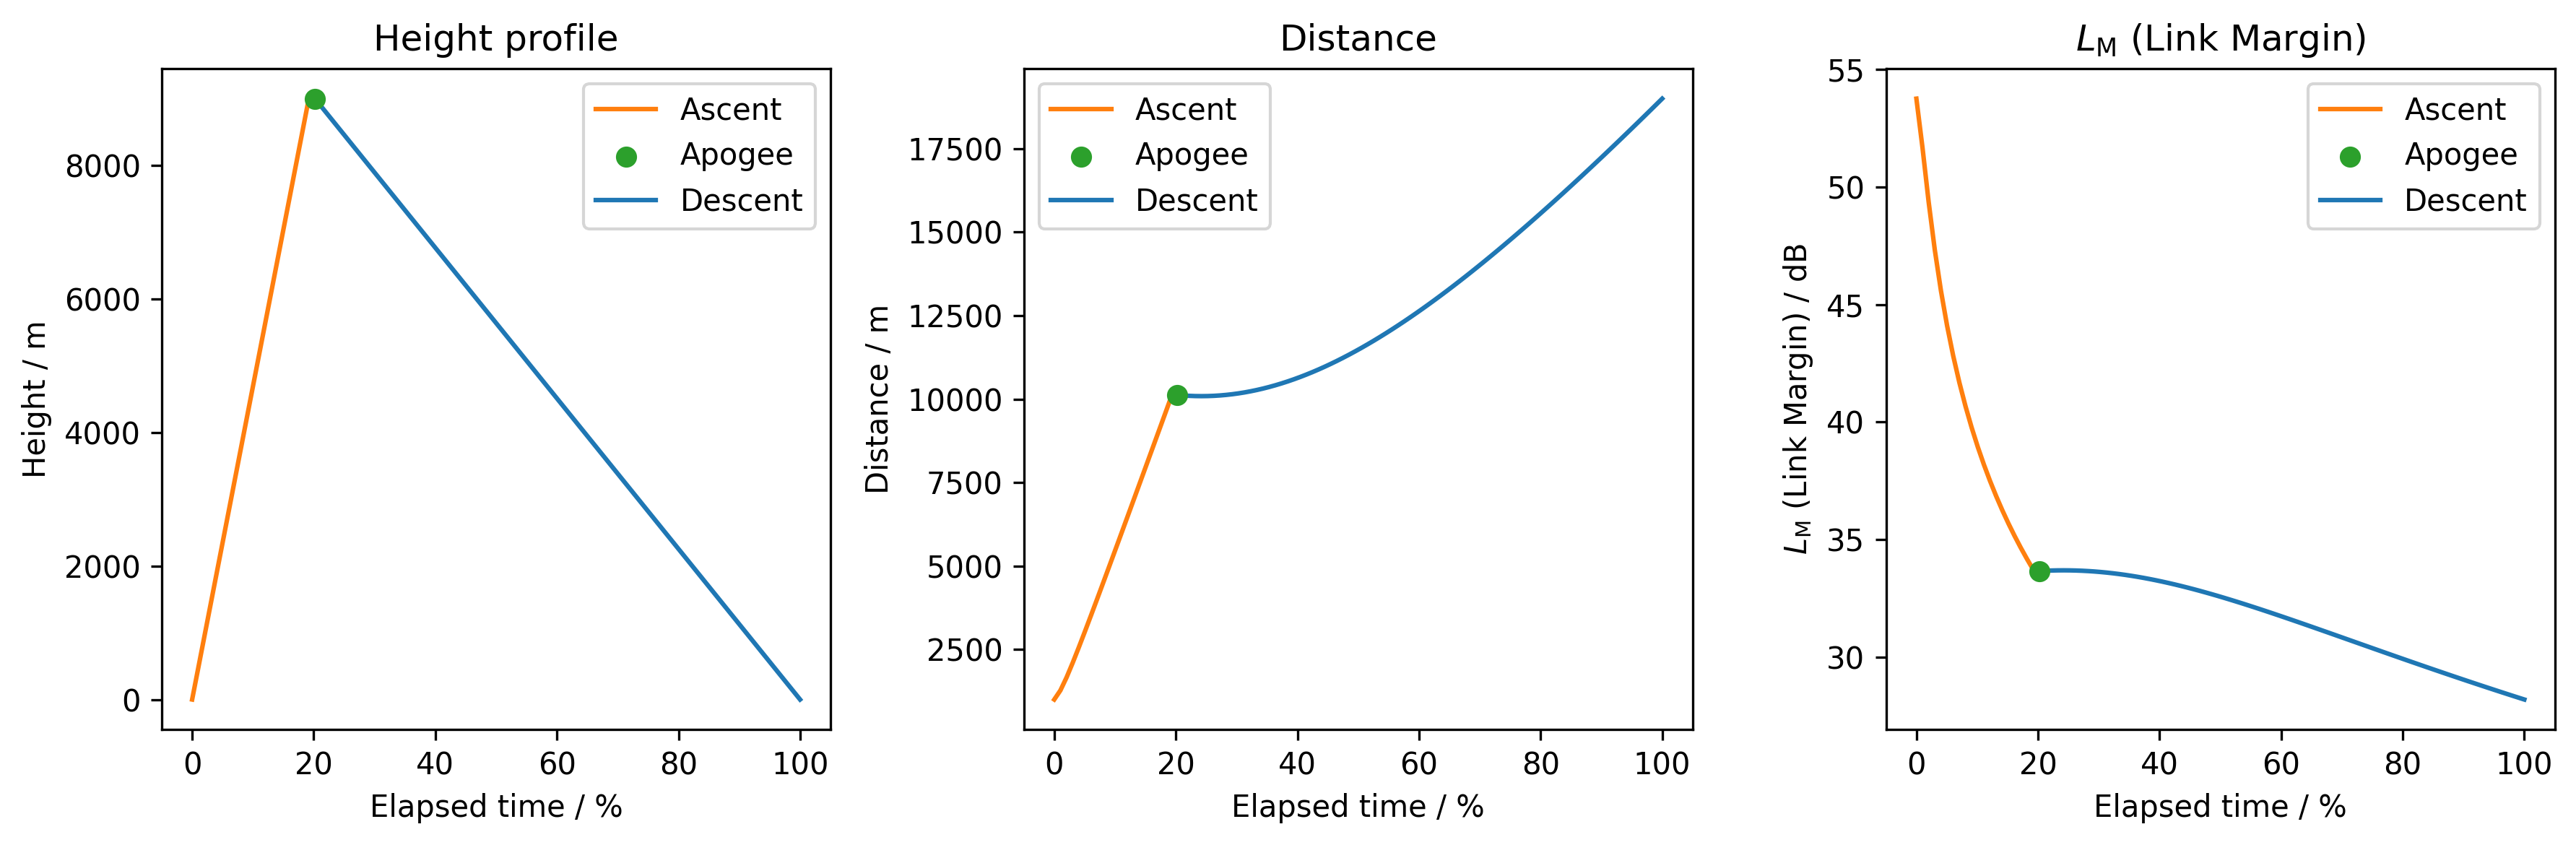

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Possible improvements of the calculation:
# - Qualified guess or even measurement of L_TX and L_RX
# - Specification receiver antenna gain G_RX
# - Inclusion of the real gain of the sending antenna G_TX
# - Realistic height profile
# - Incorporation of simulated flight data

f = 869.5e+6                # 869.5 MHz radio frequency

P_TX = 27                   # Transmit signal strength RC1780HP-RC232
G_TX = 0                    # QFH-antenna gain (real gain not equal to 0 and dependant on the angle)
L_TX = 3                    # Transmit (cable, ...) losses (guess)

P_RX = -114                 # Minimum receive signal strength RC1780HP-RC232, alternative: P_RX = -118
G_RX = 10                   # Helix antenna gain, first guess
L_RX = 3                    # Receive (cable, ...) losses (guess)

h_max = 9000                # Maximum height
d_start = 1000              # Horizontal distance at the beginning and during ascent
d_end = 19000               # Horizontal distance at the end
t_ascent = 20               # Ascent time fraction of the total time in %

time = np.linspace(0, 100, 100)
height = np.append(np.linspace(0, h_max, t_ascent), np.linspace(h_max, 0, 100 - t_ascent))      # vertical distance
displacement = np.linspace(d_start, d_end, 100)                                                 # horizontal distance
distance = np.sqrt(height**2 + displacement**2)                                                 # total distance

L_FS = 20 * np.log10((4 * np.pi * distance * f)/(2.998e+8))                                     # Free Space Attenuation

L_M = P_TX - P_RX + G_TX + G_RX - L_FS - L_TX - L_RX                                            # Link Margin

print(f'\nMinimal Link Margin during the flight: {np.min(L_M):.2f} dB')

# Plot

plt.figure(figsize=(12,4), dpi = 300)

plt.subplot(1, 3, 1)
plt.plot(time[:t_ascent], height[:t_ascent], c = 'tab:orange', label = 'Ascent')
plt.scatter(time[t_ascent], height[t_ascent], c = 'tab:green', zorder = 3, label = 'Apogee')
plt.plot(time[t_ascent:], height[t_ascent:], c = 'tab:blue', label = 'Descent')
plt.title('Height profile')
plt.xlabel('Elapsed time / %')
plt.ylabel('Height / m')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(time[:t_ascent], distance[:t_ascent], c = 'tab:orange', label = 'Ascent')
plt.scatter(time[t_ascent], distance[t_ascent], c = 'tab:green', zorder = 3, label = 'Apogee')
plt.plot(time[t_ascent:], distance[t_ascent:], c = 'tab:blue', label = 'Descent')
plt.title('Distance')
plt.xlabel('Elapsed time / %')
plt.ylabel('Distance / m')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(time[:t_ascent], L_M[:t_ascent], c = 'tab:orange', label = 'Ascent')
plt.scatter(time[t_ascent], L_M[t_ascent], c = 'tab:green', zorder = 3, label = 'Apogee')
plt.plot(time[t_ascent:], L_M[t_ascent:], c = 'tab:blue', label = 'Descent')
plt.title(r'$L_\mathrm{M}$ (Link Margin)')
plt.xlabel(r'Elapsed time / %')
plt.ylabel(r'$L_\mathrm{M}$ (Link Margin) / dB')
plt.legend()

plt.tight_layout()